In [1]:
import os
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, add_messages
from openai import OpenAI
from rich.console import Console
from rich.panel import Panel
from rich.pretty import Pretty
from pydantic import BaseModel, Field
from langchain_tavily import TavilySearch
from rich import print
from langchain.agents import create_agent
from typing import Annotated, Literal, List, TypedDict
from rich.markdown import Markdown
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.output_parsers import PydanticOutputParser
import asyncio


console = Console()

def show(response):
    console.print(
        Panel(
            # Pretty(response.model_dump()),
            Pretty(response),
            title="🤖 LLM Response",
            border_style="green",
            expand=False
        )
    )

def show_markdown(response):
    Console().print(Markdown(response))

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

llm = ChatOpenAI(
    model="stepfun/step-3.5-flash:free",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

# llm = ChatOpenAI(
#     model="deepseek/deepseek-v3.2",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="x-ai/grok-4.1-fast",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-4o-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-oss-120b",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-5-nano",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="anthropic/claude-haiku-4.5",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash-lite",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

In [2]:
class llm_state(BaseModel):
    feedback: str
    funny_flag: Literal['Funny', 'Not funny']

In [3]:
class graph_state(BaseModel):
    topic: str = Field(..., description = "Topic to create joke on")
    joke: str = Field(..., description = "The joke generated")
    feedback: str
    funny_flag: str

In [4]:
def generator(state: graph_state) -> graph_state:
    topic = state.topic
    funny_flag = state.funny_flag
    if funny_flag:
        feedback = state.feedback
        joke = llm.invoke(f"""You are a joke generator. You generated a funny joke on this topic: {topic}
        and got the following feedback:

        {feedback}

        Generate a new funny joke taking the feedback into conideration.
        """)
    else:
        joke = llm.invoke(f"You are a joke generator. You have to generate a new joke on this topic: {topic}")
    state.joke = joke.content
    return state

In [5]:
def evaluator(state: graph_state) -> graph_state:
    topic = state.topic
    joke = state.joke
    parser = PydanticOutputParser(pydantic_object=llm_state)
    response = llm.invoke(f"""You are a joke evaluator. You have to evaluate a joke on the topic: {topic}.
    You have to tell if it is funny or not and also provide feedback for further improvements.

    Joke:
    {joke}

    {parser.get_format_instructions()}
    """)
    parsed = parser.parse(response.content)
    state.feedback = parsed.feedback
    state.funny_flag = parsed.funny_flag
    return state

In [6]:
r = generator(graph_state(
    topic = 'AI',
    joke = '',
    feedback ='',
    funny_flag = ''
))

In [7]:
show(r)

╭───────────────────────────────── 🤖 LLM Response ─────────────────────────────────╮
│ graph_state(                                                                      │
│     topic='AI',                                                                   │
│     joke='Why did the AI go to therapy?\n\nBecause it had deep learning issues!', │
│     feedback='',                                                                  │
│     funny_flag=''                                                                 │
│ )                                                                                 │
╰───────────────────────────────────────────────────────────────────────────────────╯

In [8]:
r1 = evaluator(r)

In [9]:
show(r1)

╭──────────────────────────────────────────────── 🤖 LLM Response ────────────────────────────────────────────────╮
│ graph_state(                                                                                                    │
│     topic='AI',                                                                                                 │
│     joke='Why did the AI go to therapy?\n\nBecause it had deep learning issues!',                               │
│     feedback="This joke is a clever pun that effectively uses the AI term 'deep learning' in a humorous         │
│ context, playing on the idea of emotional issues discussed in therapy. It's concise and relevant to the topic.  │
│ For improvement, you could enhance it by adding a more elaborate setup or incorporating another AI-related pun  │
│ to create a compound joke, but as it stands, it's a solid one-liner that delivers a quick laugh.",              │
│     funny_flag='Funny'                                                                                          │
│ )                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [14]:
def condition(state: graph_state) -> str:
    funny_flag = state.funny_flag
    if(funny_flag == 'Funny'):
        return 'end'
    else:
        return 'generator'

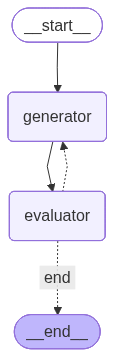

In [11]:
graph = StateGraph(graph_state)

graph.add_node('generator', generator)
graph.add_node('evaluator', evaluator)

graph.add_edge(START, 'generator')
graph.add_edge('generator', 'evaluator')
graph.add_conditional_edges('evaluator', condition, {
    'generator': 'generator', 'end': END
})

joke_graph = graph.compile()

from IPython.display import Image, display
Image(joke_graph.get_graph().draw_mermaid_png())

In [12]:
r = joke_graph.invoke(graph_state(
    topic = 'AI',
    joke = '',
    feedback ='',
    funny_flag = ''
))

In [13]:
show(r)

╭──────────────────────────────────────────────── 🤖 LLM Response ────────────────────────────────────────────────╮
│ {                                                                                                               │
│     'topic': 'AI',                                                                                              │
│     'joke': 'Why did the AI assistant apply for a job at the bakery?\n\nBecause it heard they were looking for  │
│ someone with *great* dough-mining skills.  \n(It also politely asked if it could reorganize the entire wheat    │
│ supply chain first.)',                                                                                          │
│     'feedback': "The joke effectively uses a pun on 'data mining' to create 'dough-mining', tying AI skills to  │
│ a bakery setting. The additional remark about reorganizing the wheat supply chain adds an authentic AI          │
│ over-enthusiasm twist, enhancing the humor. To improve, consider integrating the second punchline more          │
│ seamlessly or making the pun slightly more intuitive for broader audiences.",                                   │
│     'funny_flag': 'Funny'                                                                                       │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯